In [1]:

import numpy as np
import pandas as pd
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
def load_file(filepath):
    dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
    return dataframe.values


In [4]:
# load a list of files and return as a 3d numpy array
def load_group(filenames, prefix=''):
    loaded = list()
    for name in filenames:
        data = load_file(prefix + name)
        loaded.append(data)
    # stack group so that features are the 3rd dimension
    loaded = np.dstack(loaded)
    return loaded

In [5]:
# load a dataset group, such as train or test
def load_dataset_group(group, prefix=''):
    filepath = prefix + group + '/Inertial Signals/'
    # load all 9 files as a single array
    filenames = list()
    # total acceleration
    filenames += ['total_acc_x_'+group+'.txt', 'total_acc_y_'+group+'.txt', 'total_acc_z_'+group+'.txt']
    # body acceleration
    filenames += ['body_acc_x_'+group+'.txt', 'body_acc_y_'+group+'.txt', 'body_acc_z_'+group+'.txt']
    # body gyroscope
    filenames += ['body_gyro_x_'+group+'.txt', 'body_gyro_y_'+group+'.txt', 'body_gyro_z_'+group+'.txt']
    # load input data
    X = load_group(filenames, filepath)
    # load class output
    y = load_file(prefix + group + '/y_'+group+'.txt')
    return X, y

In [6]:
# load the dataset, returns train and test X and y elements
def load_dataset(prefix=''):
    # load all train
    trainX, trainy = load_dataset_group('train', prefix + '/content/drive/MyDrive/Colab Notebooks/UCI HAR Dataset/UCI HAR Dataset/')
    # load all test
    testX, testy = load_dataset_group('test', prefix + '/content/drive/MyDrive/Colab Notebooks/UCI HAR Dataset/UCI HAR Dataset/')

    #zero-offset class values
    trainy = trainy - 1
    testy = testy - 1
    #one hot encode y
    trainy_one_hot = to_categorical(trainy)
    testy_one_hot = to_categorical(testy)
    print(trainX.shape, trainy.shape, trainy_one_hot.shape, testX.shape, testy.shape, testy_one_hot.shape)
    return trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot


In [7]:
trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot = load_dataset()

/tmp/ipython-input-473047976.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-473047976.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-473047976.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-473047976.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp

(7352, 128, 9) (7352, 1) (7352, 6) (2947, 128, 9) (2947, 1) (2947, 6)


In [8]:
from sklearn.model_selection import train_test_split

X_train,X_val,y_train_one_hot,y_val_one_hot,y_train,y_val=train_test_split(trainX, trainy_one_hot, trainy,test_size=0.2,random_state=100)


In [9]:
X_train.shape,X_val.shape,y_train_one_hot.shape,y_val_one_hot.shape,y_train.shape,y_val.shape

((5881, 128, 9), (1471, 128, 9), (5881, 6), (1471, 6), (5881, 1), (1471, 1))

In [10]:
n_timesteps, n_features, n_outputs = X_train.shape[1], X_train.shape[2], y_train_one_hot.shape[1]


In [11]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LayerNormalization,
    MultiHeadAttention, GlobalAveragePooling1D, Add
)
from tensorflow.keras.optimizers import Adam
import numpy as np


In [12]:
class PositionalEncoding(tf.keras.layers.Layer):
    """Positional Encoding Layer"""

    def __init__(self, max_len=5000, d_model=128):
        super(PositionalEncoding, self).__init__()
        self.max_len = max_len
        self.d_model = d_model

    def build(self, input_shape):
        # Create positional encoding matrix
        position = np.arange(self.max_len)[:, np.newaxis]
        div_term = np.exp(np.arange(0, self.d_model, 2) * -(np.log(10000.0) / self.d_model))

        pos_encoding = np.zeros((self.max_len, self.d_model))
        pos_encoding[:, 0::2] = np.sin(position * div_term)
        pos_encoding[:, 1::2] = np.cos(position * div_term)

        self.pos_encoding = tf.constant(pos_encoding, dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.pos_encoding[:seq_len, :]


In [13]:
def transformer_encoder_block(x, d_model, num_heads, ff_dim, dropout_rate=0.1):
    """Transformer Encoder Block"""

    # Multi-head attention
    attn_output = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=d_model // num_heads,
        dropout=dropout_rate
    )(x, x)
    attn_output = Dropout(dropout_rate)(attn_output)
    x1 = Add()([x, attn_output])
    x1 = LayerNormalization(epsilon=1e-6)(x1)

    # Feed forward network
    ffn_output = Dense(ff_dim, activation='relu')(x1)
    ffn_output = Dropout(dropout_rate)(ffn_output)
    ffn_output = Dense(d_model)(ffn_output)
    ffn_output = Dropout(dropout_rate)(ffn_output)
    x2 = Add()([x1, ffn_output])
    x2 = LayerNormalization(epsilon=1e-6)(x2)

    return x2

In [14]:
def create_transformer_model(n_timesteps=128, n_features=9, n_outputs=6,
                            d_model=128, num_heads=8, num_layers=4,
                            ff_dim=512, dropout_rate=0.1):
    """
    Transformer Encoder 모델 생성 (Global Average Pooling 방식)

    Args:
        n_timesteps: 시퀀스 길이 (기본: 128)
        n_features: 입력 특징 수 (기본: 9)
        n_outputs: 출력 클래스 수 (기본: 6)
        d_model: 모델 차원 (기본: 128)
        num_heads: Attention head 수 (기본: 8)
        num_layers: Transformer 레이어 수 (기본: 4)
        ff_dim: Feed-forward 차원 (기본: 512)
        dropout_rate: Dropout 비율 (기본: 0.1)

    Returns:
        Keras Model
    """

    # Input layer
    inputs = Input(shape=(n_timesteps, n_features))

    # Project input to d_model dimension
    x = Dense(d_model)(inputs)

    # Add positional encoding
    pos_encoding = PositionalEncoding(max_len=n_timesteps, d_model=d_model)
    x = pos_encoding(x)
    x = Dropout(dropout_rate)(x)

    # Transformer encoder blocks
    for _ in range(num_layers):
        x = transformer_encoder_block(x, d_model, num_heads, ff_dim, dropout_rate)

    # Global average pooling
    x = GlobalAveragePooling1D()(x)

    # Classification head
    x = Dense(256, activation='relu')(x)
    x = Dropout(dropout_rate)(x)

    # Output layer
    outputs = Dense(n_outputs, activation='softmax')(x)

    # Create model
    model = Model(inputs=inputs, outputs=outputs, name='Transformer_HAR')

    return model

In [15]:
def create_transformer_cls_model(n_timesteps=128, n_features=9, n_outputs=6,
                                 d_model=128, num_heads=8, num_layers=4,
                                 ff_dim=512, dropout_rate=0.1):
    """
    Transformer Encoder 모델 생성 (CLS Token 방식, BERT-style)

    Args:
        n_timesteps: 시퀀스 길이 (기본: 128)
        n_features: 입력 특징 수 (기본: 9)
        n_outputs: 출력 클래스 수 (기본: 6)
        d_model: 모델 차원 (기본: 128)
        num_heads: Attention head 수 (기본: 8)
        num_layers: Transformer 레이어 수 (기본: 4)
        ff_dim: Feed-forward 차원 (기본: 512)
        dropout_rate: Dropout 비율 (기본: 0.1)

    Returns:
        Keras Model
    """

    # Input layer
    inputs = Input(shape=(n_timesteps, n_features))

    # Project input to d_model dimension
    x = Dense(d_model)(inputs)

    # Add CLS token
    cls_token = tf.keras.layers.Embedding(1, d_model)(tf.zeros((tf.shape(x)[0], 1), dtype=tf.int32))
    x = tf.concat([cls_token, x], axis=1)

    # Add positional encoding (n_timesteps + 1 for CLS token)
    pos_encoding = PositionalEncoding(max_len=n_timesteps+1, d_model=d_model)
    x = pos_encoding(x)
    x = Dropout(dropout_rate)(x)

    # Transformer encoder blocks
    for _ in range(num_layers):
        x = transformer_encoder_block(x, d_model, num_heads, ff_dim, dropout_rate)

    # Extract CLS token output
    cls_output = tf.keras.layers.Lambda(lambda x: x[:, 0])(x)

    # Classification head
    x = LayerNormalization(epsilon=1e-6)(cls_output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(dropout_rate)(x)

    # Output layer
    outputs = Dense(n_outputs, activation='softmax')(x)

    # Create model
    model = Model(inputs=inputs, outputs=outputs, name='Transformer_CLS_HAR')

    return model

In [16]:
model = create_transformer_model(
        n_timesteps=128,
        n_features=9,
        n_outputs=6,
        d_model=128,
        num_heads=8,
        num_layers=4,
        ff_dim=512,
        dropout_rate=0.1
    )


In [18]:
model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=0.0001),  # Transformer는 낮은 lr 권장
        metrics=['accuracy']
    )

    # 모델 구조 확인
model.summary()

Model: "Transformer_HAR"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128, 128)  │      1,280 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 128, 128)  │          0 │ dense[0][0]       │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128)  │          0 │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 128)  │     66,048 │ dropout[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128, 128)  │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128)  │          0 │ dropout[0][0],    │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 128, 128)  │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128, 512)  │     66,048 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128, 512)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128, 128)  │     65,664 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128, 128)  │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 128)  │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 128)  │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128, 128)  │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 128, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 128)  │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128, 512)  │     66,048 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 128, 512)  │          0 │ dense_3[0][0]   

 Total params: 828,934 (3.16 MB)

 Trainable params: 828,934 (3.16 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(X_train, y_train_one_hot,
                    epochs=20,
                    batch_size=32,
                    validation_data=(X_val, y_val_one_hot),
                    verbose=1)

Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 48s 121ms/step - accuracy: 0.3780 - loss: 1.4558 - val_accuracy: 0.5296 - val_loss: 1.0670
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6214 - loss: 0.9000 - val_accuracy: 0.7458 - val_loss: 0.5781
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.8036 - loss: 0.4983 - val_accuracy: 0.8307 - val_loss: 0.4181
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8514 - loss: 0.3587 - val_accuracy: 0.8892 - val_loss: 0.2848
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.8919 - loss: 0.2790 - val_accuracy: 0.8756 - val_loss: 0.3082
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9092 - loss: 0.2269 - val_accuracy: 0.9130 - val_loss: 0.2162
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9162 - loss: 0.2072 - val_accuracy: 0.9198 - val_loss: 0.2051
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9371 - loss: 0.1714 - val_ac

In [20]:
test_loss, test_accuracy = model.evaluate(testX, testy_one_hot, verbose=0)

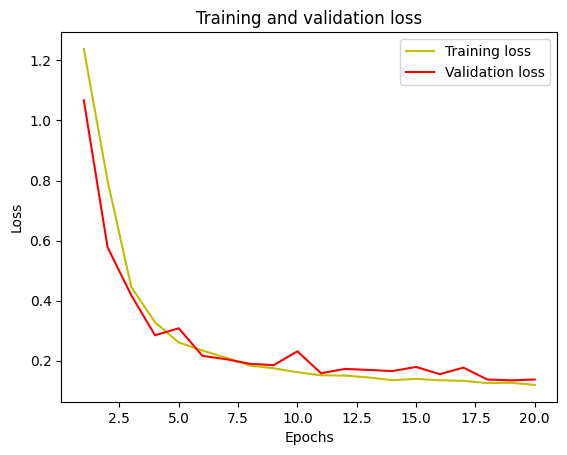

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

loss =history.history['loss']
val_loss =history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

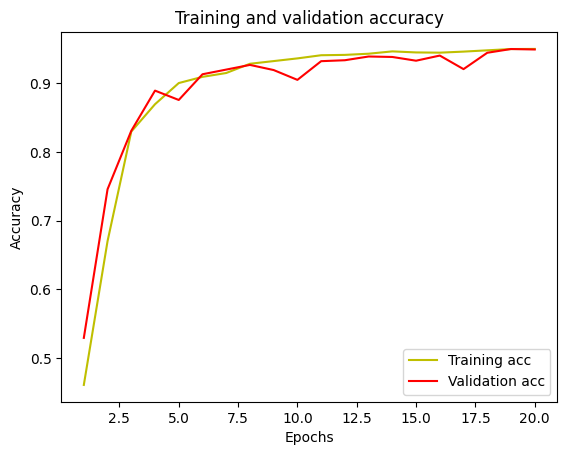

In [22]:


acc =history.history['accuracy']
val_acc =history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [23]:

from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
pred=model.predict(testX)
pred=np.argmax(pred, axis=-1)
cm=confusion_matrix(testy,pred)
print(cm)
print(accuracy_score(testy,pred))
print(classification_report(testy,pred))


93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step
[[423   0  73   0   0   0]
 [ 15 426  30   0   0   0]
 [  7   2 411   0   0   0]
 [  0   0   0 400  91   0]
 [  0   1   0 106 425   0]
 [  0  16   0   0   0 521]]
0.8842891075670173
              precision    recall  f1-score   support

           0       0.95      0.85      0.90       496
           1       0.96      0.90      0.93       471
           2       0.80      0.98      0.88       420
           3       0.79      0.81      0.80       491
           4       0.82      0.80      0.81       532
           5       1.00      0.97      0.98       537

    accuracy                           0.88      2947
   macro avg       0.89      0.89      0.88      2947
weighted avg       0.89      0.88      0.88      2947



<Axes: >

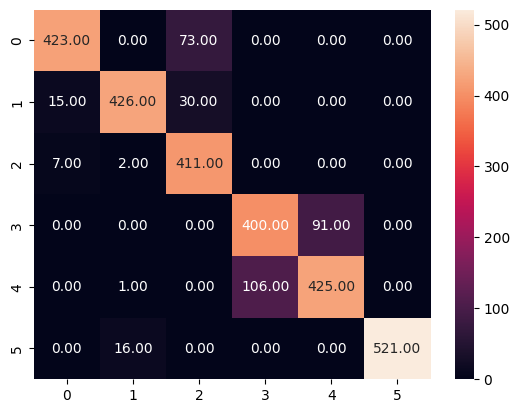

In [24]:
sns.heatmap(cm, annot=True, fmt = '.2f')